In [1]:
import sqlite3
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
conn = sqlite3.connect("../data/inventory.db")


In [3]:
tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn)
tables

,name
0,purchases
1,purchase_prices
2,vendor_invoice
3,begin_inventory
4,end_inventory


In [4]:
vendor_df = pd.read_sql_query("SELECT * FROM vendor_invoice LIMIT 5", conn)
vendor_df.head() 

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


In [5]:
purchases_df = pd.read_sql_query("SELECT * FROM purchases LIMIT 5", conn)
purchases_df.head() 

,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


In [6]:
tables =  pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn)
for table in tables['name']:
    print(f'Table: {table}')
    display(pd.read_sql_query(f"SELECT * FROM {table} LIMIT 5", conn))

Table: purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


Table: purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


Table: vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


Table: begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


Table: end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


In [7]:
purchases_agg_df = pd.read_sql_query("""
SELECT
    p.PONumber,
    COUNT(DISTINCT p.Brand)    AS total_brands,
    SUM(p.Quantity)            AS total_item_quantity,
    SUM(p.Dollars)             AS total_item_dollars,       -- use Dollars instead of Amount
    AVG(julianday(p.ReceivingDate) - julianday(p.PODate))
    AS avg_receiving_delay
FROM purchases p
GROUP BY p.PONumber
""", conn)

purchases_agg_df.head()

,PONumber,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay
0,8106,81,10100,137483.78,12.614130
1,8107,2,24,348.72,12.500000
2,8108,165,8466,60281.13,12.632479
3,8109,23,2246,14298.09,12.626866
4,8110,183,8086,56493.23,12.695271


In [8]:
purchases_agg_df.describe()

,PONumber,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay
count,5543.000000,5543.000000,5543.000000,5.543000e+03,5543.000000
mean,10889.419087,41.312466,6058.880931,5.807338e+04,7.671541
std,1600.859969,76.940674,14453.338164,1.402340e+05,1.824496
min,8106.000000,1.000000,1.000000,4.140000e+00,3.000000
25%,9503.500000,3.000000,83.000000,9.678100e+02,6.129178
50%,10890.000000,7.000000,423.000000,4.765450e+03,7.744898
75%,12275.500000,46.000000,5100.500000,4.458718e+04,9.083804
max,13661.000000,807.000000,141660.000000,1.660436e+06,13.000000


In [9]:
pd.read_sql_query("""
SELECT
*
from vendor_invoice
""", conn)

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,NaN
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,NaN
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,NaN
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,NaN
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,NaN
...,...,...,...,...,...,...,...,...,...,...
5538,9622,WEIN BAUER INC,2025-01-06,13626,2024-12-21,2025-02-10,90,1563.00,8.60,NaN
5539,9625,WESTERN SPIRITS BEVERAGE CO,2025-01-10,13661,2024-12-23,2025-02-18,4617,37300.48,186.50,NaN
5540,3664,WILLIAM GRANT & SONS INC,2025-01-02,13643,2024-12-22,2025-02-04,9848,202815.78,932.95,NaN
5541,9815,WINE GROUP INC,2025-01-03,13602,2024-12-20,2025-02-08,24747,149007.56,819.54,NaN


In [10]:
purchases_agg_df.shape

(5543, 5)

In [11]:
pd. read_sql_query("""
select
vi.PONumber,
vi.Quantity as invoice_quantity,
vi.Dollars as invoice_dollars,
vi.Freight,
(julianday(vi. InvoiceDate) - julianday(vi.PODate)) AS days_po_to_invoice,
(julianday(vi.PayDate) - julianday(vi.InvoiceDate)) AS days_to_pay
from vendor_invoice vi
""",conn)

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay
0,8124,6,214.26,3.47,14.0,43.0
1,8137,15,140.55,8.57,16.0,45.0
2,8169,5,106.60,4.61,16.0,38.0
3,8106,10100,137483.78,2935.20,23.0,24.0
4,8170,1935,15527.25,429.20,14.0,36.0
...,...,...,...,...,...,...
5538,13626,90,1563.00,8.60,16.0,35.0
5539,13661,4617,37300.48,186.50,18.0,39.0
5540,13643,9848,202815.78,932.95,11.0,33.0
5541,13602,24747,149007.56,819.54,14.0,36.0


In [12]:
df = pd. read_sql_query("""
with purchases_agg AS (
SELECT
    p.PONumber,
    COUNT(DISTINCT p.Brand)    AS total_brands,
    SUM(p.Quantity)            AS total_item_quantity,
    SUM(p.Dollars)             AS total_item_dollars,       -- use Dollars instead of Amount
    AVG(julianday(p.ReceivingDate) - julianday(p.PODate)) AS avg_receiving_delay
FROM purchases p
GROUP BY p.PONumber)

SELECT
vi.PONumber,
vi.Quantity AS invoice_quantity,
vi.Dollars AS invoice_dollars,
vi.Freight,
(julianday(vi.InvoiceDate) - julianday(vi.PODate)) AS days_po_to_invoice,
(julianday(vi.PayDate) - julianday(vi. InvoiceDate)) AS days_to_pay,
pa.total_brands,
pa.total_item_quantity,
pa.total_item_dollars,
pa.avg_receiving_delay


from vendor_invoice vi
left join purchases_agg pa
    on vi.PONumber = pa.PONumber
""",conn)

In [13]:
df.isnull().sum()

PONumber               0
invoice_quantity       0
invoice_dollars        0
Freight                0
days_po_to_invoice     0
days_to_pay            0
total_brands           0
total_item_quantity    0
total_item_dollars     0
avg_receiving_delay    0
dtype: int64

In [14]:
df.dtypes

PONumber                 int64
invoice_quantity         int64
invoice_dollars        float64
Freight                float64
days_po_to_invoice     float64
days_to_pay            float64
total_brands             int64
total_item_quantity      int64
total_item_dollars     float64
avg_receiving_delay    float64
dtype: object

In [15]:
def create_invoice_risk_label(row):
    if (abs(row['invoice_dollars'] - row['total_item_dollars']) > 5):
        return 1

    if row['avg_receiving_delay'] > 10:
        return 1
    
    return 0
df["flag_invoice"] = df.apply(create_invoice_risk_label, axis=1)
df["flag_invoice"].value_counts()

flag_invoice
0    3693
1    1850
Name: count, dtype: int64

<Axes: xlabel='flag_invoice'>

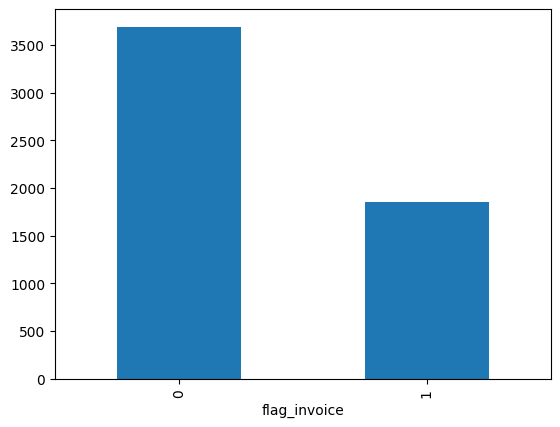

In [16]:
df['flag_invoice'].value_counts().plot(kind='bar')

In [17]:
df.corr()

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay,flag_invoice
PONumber,1.000000,0.049230,0.058917,0.043617,-0.002234,0.012558,0.013423,0.049442,0.059221,-0.042362,0.564946
invoice_quantity,0.049230,1.000000,0.963831,0.946550,0.000526,0.022284,0.566394,0.706117,0.668171,0.000519,0.032783
invoice_dollars,0.058917,0.963831,1.000000,0.985141,0.001610,0.025661,0.536952,0.667666,0.679537,0.004694,0.037994
Freight,0.043617,0.946550,0.985141,1.000000,0.003265,0.025513,0.536381,0.656616,0.670768,0.015645,0.037759
days_po_to_invoice,-0.002234,0.000526,0.001610,0.003265,1.000000,-0.370432,0.009519,0.005543,0.007931,0.515538,0.183115
days_to_pay,0.012558,0.022284,0.025661,0.025513,-0.370432,1.000000,0.020336,0.016203,0.015610,-0.029403,-0.005289
total_brands,0.013423,0.566394,0.536952,0.536381,0.009519,0.020336,1.000000,0.783825,0.753092,0.000496,0.008961
total_item_quantity,0.049442,0.706117,0.667666,0.656616,0.005543,0.016203,0.783825,1.000000,0.963831,-0.014016,0.032783
total_item_dollars,0.059221,0.668171,0.679537,0.670768,0.007931,0.015610,0.753092,0.963831,1.000000,-0.014251,0.037994
avg_receiving_delay,-0.042362,0.000519,0.004694,0.015645,0.515538,-0.029403,0.000496,-0.014016,-0.014251,1.000000,0.311667


Text(0.5, 1.0, 'Correlation Heatmap')

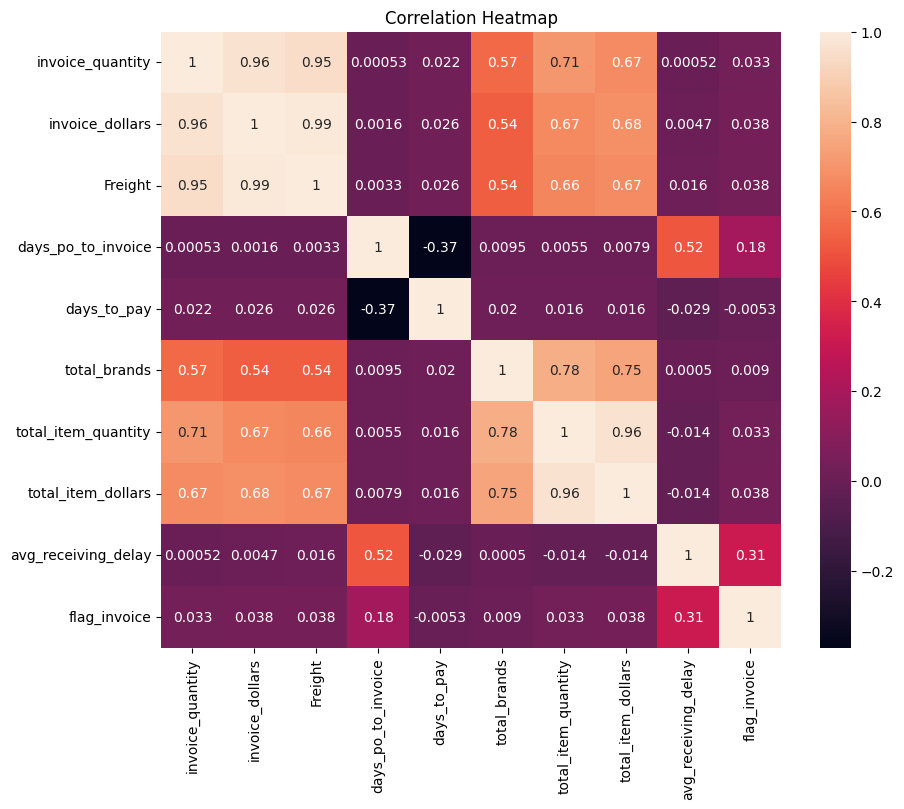

In [18]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.iloc[:, 1:].corr(), annot=True)
plt.title('Correlation Heatmap')

In [18]:
flagged = df[df['flag_invoice'] == 1]
normal = df[df['flag_invoice'] == 0]

In [19]:
significant_features = []
non_significant_features = []
results = []

In [20]:
metrics = ['invoice_quantity', 'invoice_dollars', 'Freight',
'days_po_to_invoice', 'days_to_pay', 'total_brands',
'total_item_quantity', 'total_item_dollars', 'avg_receiving_delay']

In [21]:
from scipy.stats import ttest_ind

for metric in metrics:
    flagged_mean = flagged[metric].mean()
    normal_mean = normal[metric].mean()

    # perform t-test
    t_stat, p_value = ttest_ind(flagged[metric], normal[metric], nan_policy='omit')

    if p_value < 0.05:
        significant_features.append(metric)
        results.append({
            'metric': metric,
            'flagged_mean': flagged_mean,
            'normal_mean': normal_mean,
            'p_value': p_value
        })
    else:
        non_significant_features.append(metric)

In [22]:
from scipy.stats import ttest_ind

for metric in metrics:
    flagged_mean = flagged[metric].mean()
    normal_mean = normal[metric].mean()

    t_stat, p_value = ttest_ind(
        flagged[metric].dropna(),
        normal[metric].dropna(),
        equal_var=False
    )

    if p_value < 0.05:
        significant_features.append(metric)
        results.append({
            "metric": metric,
            "flagged_mean": round(flagged_mean, 2),
            "normal_mean": round(normal_mean, 2),
            "p_value": round(p_value, 3)
        })
    else:
        non_significant_features.append(metric)

In [23]:
non_significant_features

['days_to_pay', 'total_brands', 'days_to_pay', 'total_brands']

In [24]:
significant_features

['invoice_quantity',
 'invoice_dollars',
 'Freight',
 'days_po_to_invoice',
 'total_item_quantity',
 'total_item_dollars',
 'avg_receiving_delay',
 'invoice_quantity',
 'invoice_dollars',
 'Freight',
 'days_po_to_invoice',
 'total_item_quantity',
 'total_item_dollars',
 'avg_receiving_delay']

In [25]:
X = df [['invoice_quantity', 'invoice_dollars','Freight','total_brands','total_item_quantity', 'days_po_to_invoice','total_item_dollars']]
y = df ['flag_invoice' ]

In [26]:
X.describe().round()

,invoice_quantity,invoice_dollars,Freight,total_brands,total_item_quantity,days_po_to_invoice,total_item_dollars
count,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0
mean,6059.0,58073.0,296.0,41.0,6059.0,16.0,58073.0
std,14453.0,140234.0,714.0,77.0,14453.0,3.0,140234.0
min,1.0,4.0,0.0,1.0,1.0,9.0,4.0
25%,83.0,968.0,5.0,3.0,83.0,14.0,968.0
50%,423.0,4765.0,25.0,7.0,423.0,16.0,4765.0
75%,5100.0,44587.0,230.0,46.0,5100.0,19.0,44587.0
max,141660.0,1660436.0,8468.0,807.0,141660.0,23.0,1660436.0


In [27]:
from sklearn.preprocessing import StandardScaler, minmax_scale
from sklearn.model_selection import train_test_split

scaler = StandardScaler()
# make a train/test split first
X_train, X_test, y_train, y_test = train_test_split(
    X, y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


In [29]:
model_1 = LogisticRegression(random_state=42)
model_1.fit(X_train_scaled, y_train)

model_2 = DecisionTreeClassifier(random_state=42)
model_2.fit(X_train_scaled, y_train)

model_3 = RandomForestClassifier(random_state=42)
model_3.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Logistic Regression accuracy: 0.690
              precision    recall  f1-score   support

           0       0.70      0.96      0.81       944
           1       0.58      0.11      0.18       442

    accuracy                           0.69      1386
   macro avg       0.64      0.54      0.50      1386
weighted avg       0.66      0.69      0.61      1386



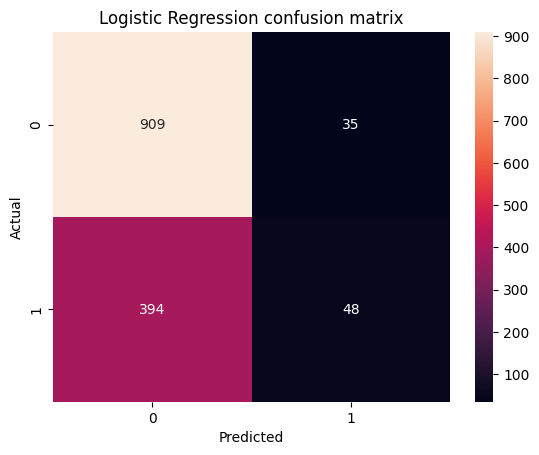

Decision Tree accuracy: 0.825
              precision    recall  f1-score   support

           0       0.87      0.88      0.87       944
           1       0.73      0.71      0.72       442

    accuracy                           0.82      1386
   macro avg       0.80      0.79      0.80      1386
weighted avg       0.82      0.82      0.82      1386



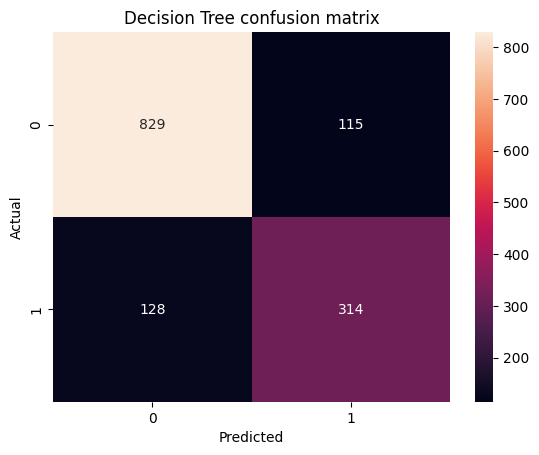

Random Forest accuracy: 0.880
              precision    recall  f1-score   support

           0       0.87      0.96      0.92       944
           1       0.90      0.70      0.79       442

    accuracy                           0.88      1386
   macro avg       0.89      0.83      0.85      1386
weighted avg       0.88      0.88      0.88      1386



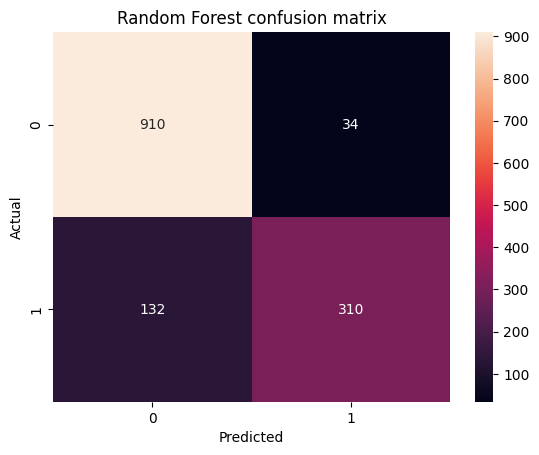

In [30]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def evaluate_model(model, X, y, name="model"):
    """predict on X, print accuracy/report and plot a confusion matrix."""
    y_pred = model.predict(X)
    print(f"{name} accuracy: {accuracy_score(y, y_pred):.3f}")
    print(classification_report(y, y_pred))
    cm = confusion_matrix(y, y_pred)
    sns.heatmap(cm, annot=True, fmt="d")
    plt.title(f"{name} confusion matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# now call it for each of the trained models
evaluate_model(model_1, X_test_scaled, y_test, 'Logistic Regression')
evaluate_model(model_2, X_test_scaled, y_test, 'Decision Tree')
evaluate_model(model_3, X_test_scaled, y_test, 'Random Forest')

In [31]:
model_3.feature_importances_

array([0.15615976, 0.15289909, 0.15333708, 0.08914626, 0.17333709,
       0.07867906, 0.19644167])

In [32]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model_3.feature_importances_
}).sort_values(by='importance', ascending=False)

feature_importance

,feature,importance
6,total_item_dollars,0.196442
4,total_item_quantity,0.173337
0,invoice_quantity,0.156160
2,Freight,0.153337
1,invoice_dollars,0.152899
3,total_brands,0.089146
5,days_po_to_invoice,0.078679


In [33]:
X = df [['invoice_quantity', 'invoice_dollars','Freight','total_item_quantity','total_item_dollars']]
y = df ['flag_invoice' ]

Random Forest (revised) accuracy: 0.885
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       725
           1       0.94      0.72      0.81       384

    accuracy                           0.88      1109
   macro avg       0.90      0.84      0.86      1109
weighted avg       0.89      0.88      0.88      1109



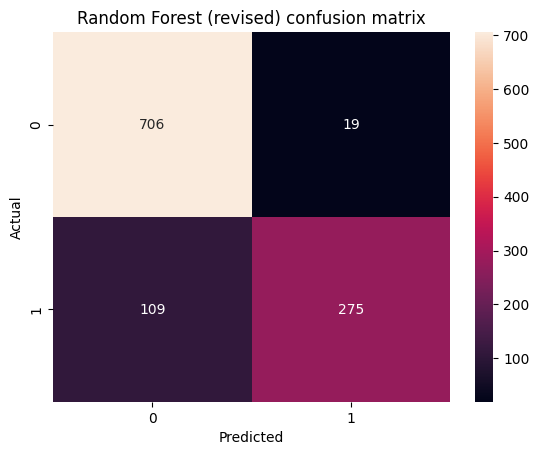

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scalar = StandardScaler()
X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.transform(X_test)

model_3 = RandomForestClassifier(random_state=42)
model_3.fit(X_train_scaled, y_train)

evaluate_model(model_3, X_test_scaled, y_test, 'Random Forest (revised)')

Random Forest (tuned) accuracy: 0.890
              precision    recall  f1-score   support

           0       0.87      0.98      0.92       725
           1       0.96      0.71      0.82       384

    accuracy                           0.89      1109
   macro avg       0.91      0.85      0.87      1109
weighted avg       0.90      0.89      0.89      1109



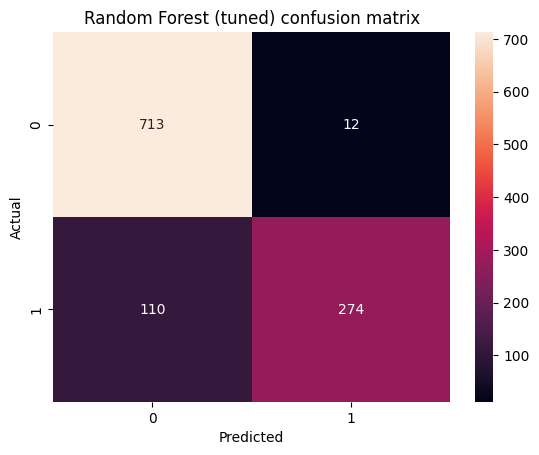

In [35]:
from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(
    random_state=42, 
    n_jobs=-1
)

param_grid = {
    "n_estimators": [100,200, 300],
    "max_depth": [None, 4, 5, 6],
    "min_samples_split": [2, 3, 5],
    "min_samples_leaf": [1, 2, 5],
    "criterion": ['gini','entropy']
}

scorer = make_scorer(f1_score)
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring=scorer,
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)
evaluate_model(grid_search.best_estimator_, X_test_scaled, y_test, 'Random Forest (tuned)')

In [ ]:
estimator.fit(X_train)    # no y passed


ValueError: 
All the 1080 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1080 fits failed with the following error:
Traceback (most recent call last):
  File "e:\DS and ML projects\ML projects\Invoice Intelligence System\venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 831, in _fit_and_score
    estimator.fit(X_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^
  File "e:\DS and ML projects\ML projects\Invoice Intelligence System\venv\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
TypeError: BaseForest.fit() missing 1 required positional argument: 'y'
